In [2]:
# 1) 한 번만: 압축 풀기
!tar xzf EnglishFnt.tgz -C sample_data/


gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now


In [1]:
!pip install "protobuf==3.20.3" tflite-support

In [2]:
# ────────────────────────────────────────────────────────────────
# 0) EnglishFnt에서 D/N/E 데이터셋 자동 구축
# ────────────────────────────────────────────────────────────────
import os
from pathlib import Path
from PIL import Image
import shutil
import random

# 원본 폰트 이미지 경로
FNT_BASE = Path("sample_data/English/Fnt")
OUT_BASE = Path("dataset")
CLASS_MAP = {'Sample014': 'D', 'Sample024': 'N', 'Sample015': 'E'}

# dataset/D, dataset/N, dataset/E 폴더 생성 및 초기화
for c in ['D', 'N', 'E']:
    d = OUT_BASE / c
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# 클래스별로 파일 복사 (최대 2000장씩 샘플)
for sample, label in CLASS_MAP.items():
    src = FNT_BASE / sample
    dst = OUT_BASE / label
    files = list(src.glob("*.png"))
    random.shuffle(files)
    for i, f in enumerate(files[:2000]):
        img = Image.open(f).convert("L").resize((32,32))
        img.save(dst / f"{label}_{i:04d}.png")

print("✅ EnglishFnt → dataset/D,N,E 자동 구축 완료")

# ────────────────────────────────────────────────────────────────
# 1) Keras 데이터셋 로드 및 증강
# ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE    = (32, 32)
BATCH_SIZE  = 64
EPOCHS      = 20
TFLITE_PATH = "dne_classifier.tflite"
CLASS_NAMES = ["D", "N", "E"]
VALID_SPLIT = 0.2
SEED        = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="training",
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="validation",
    seed=SEED
)

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomRotation(0.1),
])

def preprocess_train(x, y):
    x = tf.expand_dims(x, -1) if x.shape[-1] != 1 else x
    x = data_augmentation(x)
    x = normalization(x)
    return x, y

train_ds = train_ds.map(preprocess_train).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# ────────────────────────────────────────────────────────────────
# 2) CNN 모델 정의 및 학습
# ────────────────────────────────────────────────────────────────
def build_dne_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_dne_model(IMG_SIZE + (1,), len(CLASS_NAMES))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ────────────────────────────────────────────────────────────────
# 3) TFLite 변환 및 저장
# ────────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)
print(f"✅ 3-class TFLite model saved at '{TFLITE_PATH}'")

# ────────────────────────────────────────────────────────────────
# 4) labels.txt 생성 (메타데이터용)
# ────────────────────────────────────────────────────────────────
with open("labels.txt", "w") as f:
    f.write("D\nN\nE\n")
print("✅ labels.txt 생성 완료")

# ────────────────────────────────────────────────────────────────
# 5) TFLite 메타데이터 포함시키기 (tflite-support 필요)
# ────────────────────────────────────────────────────────────────
try:
    from tflite_support.metadata_writers import image_classifier
    from tflite_support.metadata_writers import writer_utils

    MODEL_PATH = TFLITE_PATH
    LABEL_FILE = "labels.txt"
    EXPORT_MODEL = "dne_classifier_with_metadata.tflite"

    writer = image_classifier.MetadataWriter.create_for_inference(
        writer_utils.load_file(MODEL_PATH),
        input_norm_mean=[0.0],     # 보통 x/255.0로 정규화하면 0.0, 1.0
        input_norm_std=[1.0],
        label_file_paths=[LABEL_FILE]
    )
    metadata_buf = writer.populate()

    with open(EXPORT_MODEL, "wb") as f:
        f.write(metadata_buf)
    print(f"✅ 메타데이터 포함 tflite 저장 완료: {EXPORT_MODEL}")
except ImportError:
    print("❗️ tflite-support가 설치되어 있지 않습니다. pip install tflite-support 먼저 실행하세요.")


✅ EnglishFnt → dataset/D,N,E 자동 구축 완료
Found 3048 files belonging to 3 classes.
Using 2439 files for training.
Found 3048 files belonging to 3 classes.
Using 609 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,619 (2.07 MB)

 Trainable params: 543,619 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.6035 - loss: 0.8659 - val_accuracy: 0.9704 - val_loss: 0.0977
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9375 - loss: 0.1727 - val_accuracy: 0.9688 - val_loss: 0.0911
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9521 - loss: 0.1367 - val_accuracy: 0.9737 - val_loss: 0.0538
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9648 - loss: 0.0936 - val_accuracy: 0.9787 - val_loss: 0.0512
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9697 - loss: 0.0837 - val_accuracy: 0.9852 - val_loss: 0.0420
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9719 - loss: 0.0755 - val_accuracy: 0.9885 - val_loss: 0.0315
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9747 - loss: 0.0708 - val_accuracy: 0.9836 - val_loss: 0.0417
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9814 - loss: 0.0619 - val_accuracy: 0.9934 - v

In [3]:
!pip install opencv-python-headless

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


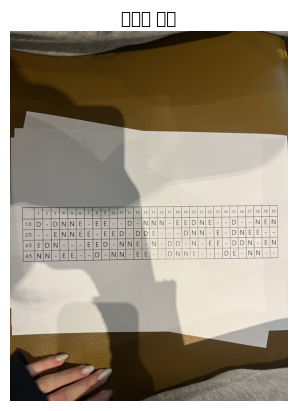

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


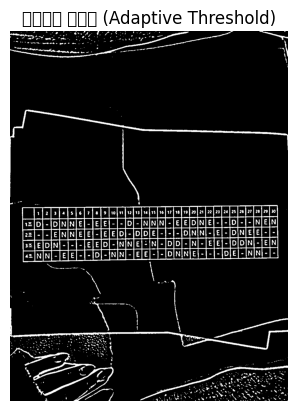

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44285 (\N{HANGUL SYLLABLE GWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

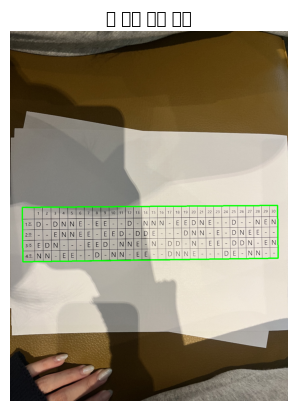

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47148 (\N{HANGUL SYLLABLE RYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


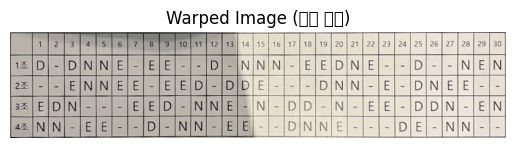

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from google.colab import files

img_path = "/content/schedule9.jpeg"
image = cv2.imread(img_path)

if image is None:
    raise FileNotFoundError(f"이미지를 불러올 수 없습니다: {img_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("이미지 확인")
plt.axis('off')
plt.show()

# 크기 제한 (선택사항)
max_width = 1000
if image.shape[1] > max_width:
    scale = max_width / image.shape[1]
    image = cv2.resize(image, None, fx=scale, fy=scale)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
thresh = cv2.adaptiveThreshold(
    blur, 200, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 8
)

plt.imshow(thresh, cmap='gray')
plt.title("이진화된 이미지 (Adaptive Threshold)")
plt.axis('off')
plt.show()

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

table_contour = None
for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    if len(approx) == 4:
        table_contour = approx
        break

if table_contour is None:
    print("❌ 표를 찾지 못했습니다.")
else:
    temp = image.copy()
    cv2.drawContours(temp, [table_contour], -1, (0, 255, 0), 3)
    plt.imshow(temp)
    plt.title("표 외곽 검출 결과")
    plt.axis('off')
    plt.show()

def sort_points(pts):
    pts = pts.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect

# 정렬 좌표 계산
rect = sort_points(table_contour)
(tl, tr, br, bl) = rect
widthA = np.linalg.norm(br - bl)
widthB = np.linalg.norm(tr - tl)
maxWidth = max(int(widthA), int(widthB))
heightA = np.linalg.norm(tr - br)
heightB = np.linalg.norm(tl - bl)
maxHeight = max(int(heightA), int(heightB))

# Warp
dst = np.array([[0, 0], [maxWidth - 1, 0],
                [maxWidth - 1, maxHeight - 1], [0, maxHeight - 1]], dtype="float32")
M = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

plt.imshow(warped)
plt.title("Warped Image (정렬 완료)")
plt.axis('off')
plt.show()

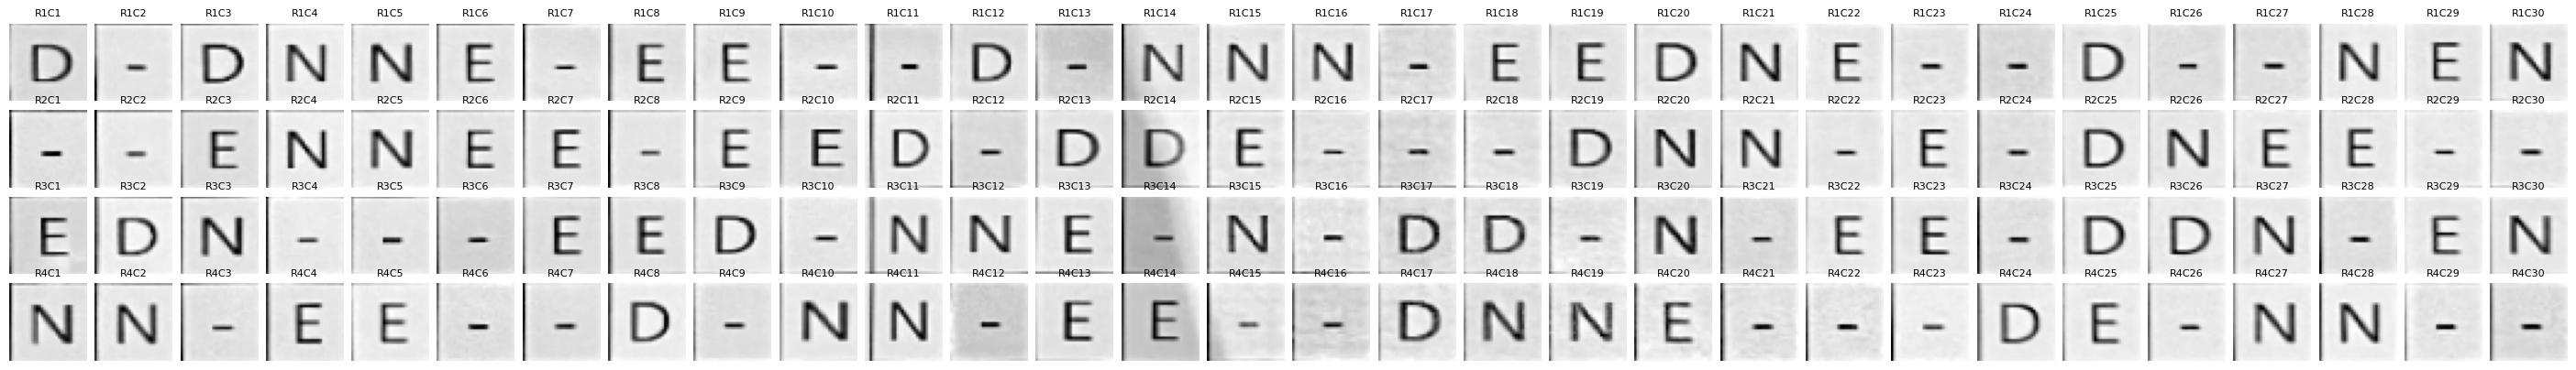

In [55]:
def tight_crop_and_resize(cell_img, out_size=(32, 32), margin=1):
    """
    1) 이진화(threshold) 후 반전(inv) → non-zero 영역 좌표(coord) 구하기
    2) boundingRect로 (x,y,w,h) 계산 후 margin만큼 안쪽 크롭
    3) out_size로 리사이즈
    """
    if cell_img is None or cell_img.size == 0:
        return np.full(out_size, 255, dtype=np.uint8)

    _, th = cv2.threshold(cell_img, 200, 255, cv2.THRESH_BINARY)
    inv = 255 - th
    coords = cv2.findNonZero(inv)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x1 = max(0, x + margin)
        y1 = max(0, y + margin)
        x2 = min(cell_img.shape[1], x + w - margin)
        y2 = min(cell_img.shape[0], y + h - margin)
        cropped = cell_img[y1:y2, x1:x2] if y2>y1 and x2>x1 else cell_img
    else:
        cropped = cell_img

    return cv2.resize(cropped, out_size, interpolation=cv2.INTER_AREA)

# ─────────────────────────────────────
# warped: 투시 보정된 테이블 이미지 준비되어 있다고 가정
# get_table_cells()도 이미 정의되어 있음
# ─────────────────────────────────────
gray_warped, row_ranges, col_ranges = get_table_cells(
    warped, skip_rows=1, skip_cols=1
)

# ─────────────────────────────────────
# 셀별 전처리 & 저장 & 작은 썸네일 시각화
# ─────────────────────────────────────
n_rows, n_cols = len(row_ranges), len(col_ranges)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 1.2, n_rows * 1.2),
    dpi=100,
    squeeze=False
)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for i, (y1, y2) in enumerate(row_ranges):
    for j, (x1, x2) in enumerate(col_ranges):
        # 원본 셀 크롭 + 그레이스케일
        cell_color = warped[y1:y2, x1:x2]
        cell_gray  = cv2.cvtColor(cell_color, cv2.COLOR_RGB2GRAY)

        # 전처리: margin 적용 크롭 + 32×32 리사이즈
        cell_pre = tight_crop_and_resize(cell_gray, out_size=(32,32), margin=1)

        # 파일로 저장 (디버깅용)
        cv2.imwrite(f'cell_r{i+1}_c{j+1}_pre.png', cell_pre)

        # 썸네일 시각화
        ax = axes[i, j]
        ax.imshow(cell_pre, cmap='gray')
        ax.set_title(f'R{i+1}C{j+1}', fontsize=8)
        ax.axis('off')

plt.show()

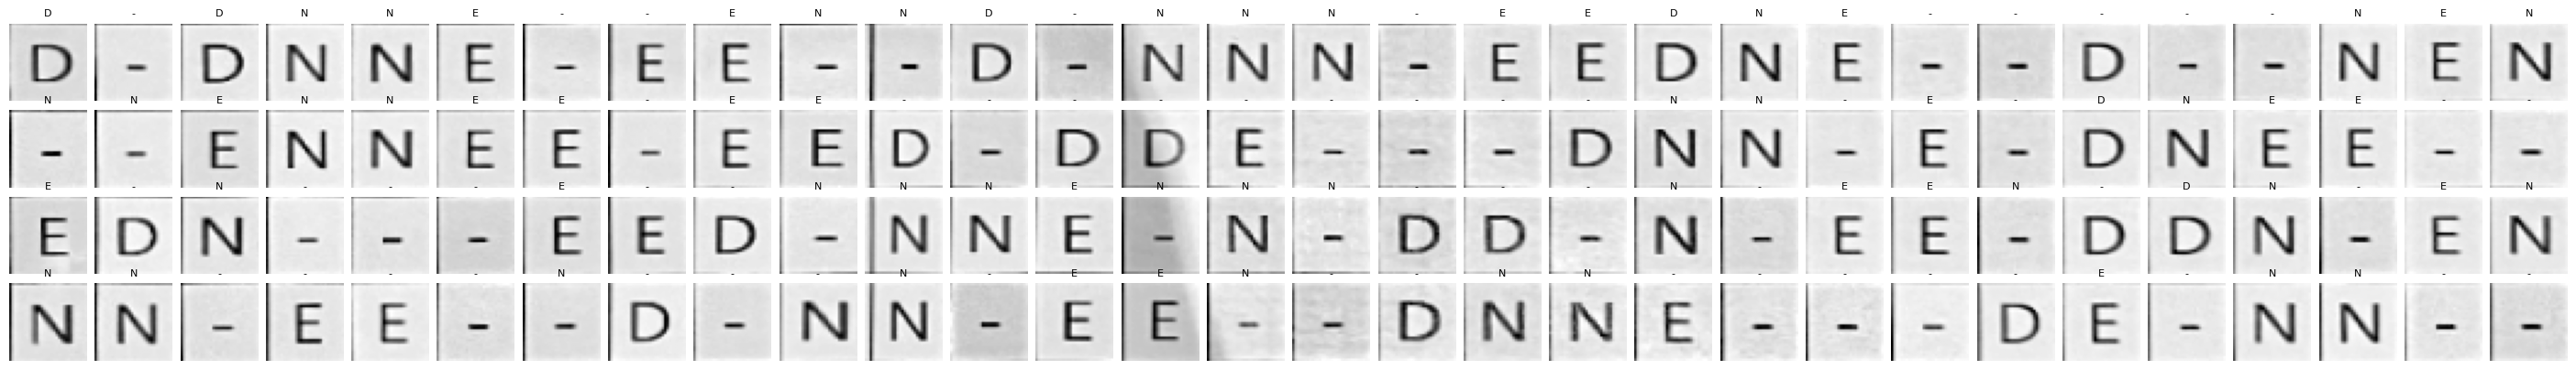

✅ inferred_schedule.json 생성 완료
{
  "1조": {
    "1": "D",
    "2": "-",
    "3": "D",
    "4": "N",
    "5": "N",
    "6": "E",
    "7": "-",
    "8": "-",
    "9": "E",
    "10": "N",
    "11": "N",
    "12": "D",
    "13": "-",
    "14": "N",
    "15": "N",
    "16": "N",
    "17": "-",
    "18": "E",
    "19": "E",
    "20": "D",
    "21": "N",
    "22": "E",
    "23": "-",
    "24": "-",
    "25": "-",
    "26": "-",
    "27": "-",
    "28": "N",
    "29": "E",
    "30": "N"
  },
  "2조": {
    "1": "N",
    "2": "N",
    "3": "E",
    "4": "N",
    "5": "N",
    "6": "E",
    "7": "E",
    "8": "-",
    "9": "E",
    "10": "E",
    "11": "-",
    "12": "-",
    "13": "-",
    "14": "-",
    "15": "-",
    "16": "-",
    "17": "-",
    "18": "-",
    "19": "-",
    "20": "N",
    "21": "N",
    "22": "-",
    "23": "E",
    "24": "-",
    "25": "D",
    "26": "N",
    "27": "E",
    "28": "E",
    "29": "-",
    "30": "-"
  },
  "3조": {
    "1": "E",
    "2": "-",
    "3": "N",
    "

In [56]:
import cv2
import numpy as np
import tensorflow as tf
import json

# ─────────────────────────────────────
# 1) TFLite 모델 로드
# ─────────────────────────────────────
MODEL_PATH = 'dne_classifier_with_metadata.tflite'
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ─────────────────────────────────────
# 2) 분류 함수 정의
# ─────────────────────────────────────
WHITE_THRESH_PIXELS = 0.02   # 전체 픽셀 중 검은색(<128) 픽셀이 1% 미만이면 blank
CONFIDENCE_THRESH  = 0.98   # 모델 최고확률이 % 미만이면 blank
CLASS_LABELS  = ['D', 'N', 'E']


def classify_dne(cell_img,
                 interpreter,
                 input_details,
                 output_details,
                 debug=False,
                 r=0,
                 c=0):
    """
    개선된 blank vs N 구분:
      1) morphology open → grid 제거
      2) tight crop & resize
      3) 검은색 픽셀 비율로 blank 판단
      4) TFLite 추론 → 최고확률 기준으로 재판단
    """
    # 1) 그리드 라인 제거 (기존대로)
    h, w = cell_img.shape
    hor_k = cv2.getStructuringElement(cv2.MORPH_RECT, (w//2, 1))
    ver_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h//2))
    no_h = cv2.morphologyEx(cell_img, cv2.MORPH_OPEN, hor_k)
    no_v = cv2.morphologyEx(no_h, cv2.MORPH_OPEN, ver_k)
    cleaned = cv2.subtract(cell_img, no_v)

    # 2) tight crop & resize (margin=2, 32×32)
    processed = tight_crop_and_resize(
        cleaned,
        out_size=(input_details[0]['shape'][1],
                  input_details[0]['shape'][2]),
        margin=1
    )

    # 3) 검은색 픽셀 비율 계산 → blank 판단
    black_ratio = np.mean(processed < 128)
    if debug:
        print(f"[DBG] black_ratio={black_ratio:.3f}")
    if black_ratio < WHITE_THRESH_PIXELS:
        return '-'

    # 4) 모델 입력 준비 및 추론
    sample = (processed.astype(np.float32) / 255.0).reshape(1, *processed.shape, 1)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]['index'])[0]
    max_p = np.max(probs)
    idx  = np.argmax(probs)
    label = CLASS_LABELS[idx]
    if debug:
        print(f"[DBG] probs={probs}, max_p={max_p:.3f}")
    # 5) 확신도 기준으로 blank 재판단
    if max_p < CONFIDENCE_THRESH:
        return '-'
    return label


# 2) 셀 경계 검출 (첫 열 그룹 레이블은 건너뜀)
gray_warped, row_ranges, col_ranges = get_table_cells(
    warped, skip_rows=1, skip_cols=1
)

# 3) 분류 및 시각화 준비
n_rows, n_cols = len(row_ranges), len(col_ranges)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 1.2, n_rows * 1.2),
    dpi=100,
    squeeze=False
)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

result = {}
for i, (y1, y2) in enumerate(row_ranges):
    row_key = f'{i+1}조'
    result[row_key] = {}
    for j, (x1, x2) in enumerate(col_ranges):
        # (a) 셀 크롭 → 그레이스케일 → 전처리
        cell_color = warped[y1:y2, x1:x2]
        cell_gray  = cv2.cvtColor(cell_color, cv2.COLOR_RGB2GRAY)
        cell_pre   = tight_crop_and_resize(cell_gray, out_size=(32,32), margin=1)

        # (b) 분류
        label = classify_dne(
            cell_pre,
            interpreter,
            input_details,
            output_details
        )

        # (c) 결과 저장
        result[row_key][f'{j+1}'] = label

        # (d) 시각화: 전처리된 셀 + 라벨
        ax = axes[i, j]
        ax.imshow(cell_pre, cmap='gray')
        ax.set_title(label, fontsize=8)
        ax.axis('off')

# 4) 결과 출력 & JSON 저장
plt.show()

with open('inferred_schedule.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("✅ inferred_schedule.json 생성 완료")
print(json.dumps(result, ensure_ascii=False, indent=2))